<a href="https://colab.research.google.com/github/p0xwave/HSE-ML-Course/blob/main/notebooks/AI_HW6_uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [ ]:
!pip install gdown -q

In [ ]:
import gdown

url = 'https://drive.google.com/uc?id=1Jt_qbTvrAIJ516Rg-QW2vzpFkbdF0ezm'
output = 'Data.zip'
gdown.download(url, output, quiet=False)

In [ ]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [3]:
!unzip AGGS_FINAL.csv.zip

Archive:  AGGS_FINAL.csv.zip
  inflating: AGGS_FINAL.csv          


<h2>Описание данных</h2>

\Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h3> Contracts </h3> Таблица с покупками продуктов

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

### Подгрузка данных

In [1]:
import pandas as pd

In [2]:
aggs = pd.read_csv('AGGS_FINAL.csv')
campaigns = pd.read_csv('CAMPAINGS.csv')
contracts = pd.read_csv('CONTRACTS_FINAL.csv')
people = pd.read_csv('PEOPLE_IN_CAMPAINGS_FINAL.csv')

In [3]:
aggs

,Unnamed: 0,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,user_id,age,city
0,104548,0.654343,-1.439286,-0.011475,2.039457,0.843580,-0.977480,-0.768019,-1.044127,0.025673,2025-01-31,1066338,26,Ufa
1,38396,2.583579,1.755569,3.360186,-1.122864,0.034201,-0.269607,-1.503646,1.040289,-1.691606,2024-11-30,13900,35,Ufa
2,227077,0.296030,-0.937075,1.073280,1.874636,-0.981216,-1.100187,-0.331181,-1.575637,0.474965,2025-03-31,4063636,28,Ufa
3,304649,2.329328,-1.345159,0.345066,0.755373,-0.082842,0.028439,0.919211,0.808793,-0.560004,2025-03-31,1025488,27,Moscow
4,239518,0.167643,1.587099,0.165357,0.289758,-1.108840,-1.501819,0.615588,1.631203,-0.208419,2025-02-28,4040555,37,Moscow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2759995,100191,0.311284,-0.232406,-0.208223,1.006051,-1.498279,0.306518,1.135627,1.169791,-0.106392,2025-02-28,61957,38,Ufa
2759996,342943,-1.970020,1.180142,-0.572525,1.052022,-0.654687,0.744590,-2.342623,-0.136155,0.582400,2025-01-31,132172,40,Moscow
2759997,186830,0.403995,-0.350153,-0.584462,0.123843,-1.015746,0.922963,1.549083,1.210031,-0.706992,2025-03-31,4028256,34,Smolensk
2759998,76230,2.218275,-0.344427,1.281239,3.781907,3.658907,1.282129,0.324350,0.982721,2.046261,2025-02-28,1097844,40,Smolensk


In [4]:
!campaigns

/bin/bash: line 1: campaigns: command not found


In [5]:
contracts

,Unnamed: 0,user_id,contract_date,product_id,contract_id
0,39735,4008279,2024-11-03,1,0001_2024-11-03_4008279
1,44062,2079035,2024-11-08,1,0001_2024-11-08_2079035
2,9286,103088,2024-11-13,1,0001_2024-11-13_103088
3,45573,2026788,2024-11-02,1,0001_2024-11-02_2026788
4,150378,52269,2024-11-17,1,0001_2024-11-17_52269
...,...,...,...,...,...
286311,34316,1117397,2024-11-28,1,0001_2024-11-28_1117397
286312,101067,2071348,2024-11-12,1,0001_2024-11-12_2071348
286313,5389,4061197,2024-11-07,1,0001_2024-11-07_4061197
286314,33660,1139038,2024-11-02,1,0001_2024-11-02_1139038


In [6]:
!people

/bin/bash: line 1: people: command not found


In [7]:
!aggs.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)
campaigns.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)
contracts.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)
people.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

/bin/bash: -c: line 1: syntax error near unexpected token `columns=['Unnamed: 0'],'
/bin/bash: -c: line 1: `aggs.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)'


In [8]:
aggs['report_dt'] = pd.to_datetime(aggs['report_dt'])
contracts['contract_date'] = pd.to_datetime(contracts['contract_date'])
people['delivery_date'] = pd.to_datetime(people['delivery_date'], errors='coerce')

In [9]:
print(f"aggs:      {aggs.shape}")
print(f"campaigns: {campaigns.shape}")
print(f"contracts: {contracts.shape}")
print(f"people:    {people.shape}")

aggs:      (2760000, 14)
campaigns: (4, 3)
contracts: (286316, 4)
people:    (520000, 4)


### Анализ

In [10]:
from datetime import timedelta

In [11]:
!python -V

Python 3.11.13


In [12]:
group_sizes = people.groupby(['campaing_id', 't_flag']).size().unstack(fill_value=0)
group_sizes.columns = ['control', 'treatment']
group_sizes['total'] = group_sizes['control'] + group_sizes['treatment']
group_sizes['treatment_rate'] = group_sizes['treatment'] / group_sizes['total']

print("Размеры групп:")
group_sizes

Размеры групп:


,control,treatment,total,treatment_rate
campaing_id,,,,
idclip,60000,60000,120000,0.5
iddqd,80000,80000,160000,0.5
iddt,60000,60000,120000,0.5
idkfa,60000,60000,120000,0.5


In [13]:
# Проверка delivery_date

for cid in people['campaing_id'].unique():
    df_c = people[people['campaing_id'] == cid]
    t1 = df_c[df_c['t_flag'] == 1]
    t0 = df_c[df_c['t_flag'] == 0]
    t1_missing = t1['delivery_date'].isna().sum()
    t0_has_date = t0['delivery_date'].notna().sum()
    print(f"{cid}: treatment без даты={t1_missing}/{len(t1)}, "
          f"control с датой={t0_has_date}/{len(t0)}")

idclip: treatment без даты=0/60000, control с датой=0/60000
iddqd: treatment без даты=0/80000, control с датой=0/80000
iddt: treatment без даты=0/60000, control с датой=0/60000
idkfa: treatment без даты=0/60000, control с датой=0/60000


In [14]:
# Диапазоны delivery_date

for cid in people['campaing_id'].unique():
    df_t = people[(people['campaing_id'] == cid) & (people['t_flag'] == 1)]
    if df_t['delivery_date'].notna().any():
        print(f"{cid}: {df_t['delivery_date'].min()} .. {df_t['delivery_date'].max()}")
    else:
        print(f"{cid}: НЕТ корректных дат")

idclip: 2024-11-04 00:00:00 .. 2024-11-08 00:00:00
iddqd: 2024-11-04 00:00:00 .. 2024-11-08 00:00:00
iddt: 2024-11-04 00:00:00 .. 2024-11-08 00:00:00
idkfa: 2024-11-04 00:00:00 .. 2024-11-08 00:00:00


In [15]:
# Пересечения клиентов между кампаниями

user_campaign_count = people.groupby('user_id')['campaing_id'].nunique()
multi_campaign = (user_campaign_count > 1).sum()
multi_campaign

np.int64(60000)

In [16]:
# Детальный анализ пересечений
treatment_only = people[people['t_flag'] == 1][['campaing_id', 'user_id']]
user_campaigns = treatment_only.groupby('user_id')['campaing_id'].apply(set)
multi = user_campaigns[user_campaigns.apply(len) > 1]

print(f"Клиентов в treatment 2+ кампаний: {len(multi)}")

Клиентов в treatment 2+ кампаний: 0


In [17]:
from itertools import combinations

for flag_combo in [(0,0), (0,1), (1,0)]:
    pair_counts = {}

    for cid in people['campaing_id'].unique():
        users = set(people[
            (people['campaing_id'] == cid) &
            (people['t_flag'] == flag_combo[0])
        ]['user_id'])

        for cid2 in people['campaing_id'].unique():
            if cid >= cid2:
                continue
            users2 = set(people[
                (people['campaing_id'] == cid2) &
                (people['t_flag'] == flag_combo[1])
            ]['user_id'])

            overlap = len(users & users2)
            if overlap > 0:
                pair_counts[(cid, cid2)] = overlap

    label = f"t_flag={flag_combo[0]} ∩ t_flag={flag_combo[1]}"
    print(f"\n{label}:")
    if pair_counts:
        for pair, cnt in sorted(pair_counts.items(), key=lambda x: -x[1]):
            c1ch = campaigns.set_index('campaing_id').loc[pair[0], 'channel']
            c2ch = campaigns.set_index('campaing_id').loc[pair[1], 'channel']
            print(f"  {pair[0]}({c1ch}) ∩ {pair[1]}({c2ch}): {cnt} клиентов")
    else:
        print("  пересечений нет")


t_flag=0 ∩ t_flag=0:
  пересечений нет

t_flag=0 ∩ t_flag=1:
  idclip(sms) ∩ iddqd(push): 60000 клиентов

t_flag=1 ∩ t_flag=0:
  пересечений нет


60 000 клиентов, которые составляют контрольную группу idclip(sms), одновременно являются treatment-группой iddqd(push) — то есть они получили push-уведомление.

Uplift SMS посчитать невозможно — контрольная группа не чистая, она уже «обработана» другим каналом. Разность будет измерять не эффект SMS, а разницу между SMS и push.

#### сборка датасета

In [18]:
CAMPAIGN_START = pd.Timestamp('2024-11-01')
TREATMENT_WINDOW_DAYS = 14
CONTROL_WINDOW_DAYS   = 21

# Контракты только по продукту 1 и за ноябрь
contracts_nov = contracts[
    (contracts['product_id'] == 1) &
    (contracts['contract_date'].dt.year == 2024) &
    (contracts['contract_date'].dt.month == 11)
].copy()

print(f"\nКонтрактов (продукт 1, ноябрь 2024): {len(contracts_nov)}")

def build_target_for_campaign(campaign_id, channel_name):
    """
    Собирает таргет для одной кампании.
    Возвращает DataFrame: user_id, report_dt, target, t_flag
    """
    df = people[people['campaing_id'] == campaign_id].copy()

    # --- Проверка критических проблем ---
    t1 = df[df['t_flag'] == 1]

    # Проблема 1: нет дат доставки у treatment-группы
    if t1['delivery_date'].isna().all():
        print(f"  ⚠ [{campaign_id}] ПРОПУСК: все delivery_date отсутствуют у treatment")
        return None

    # Проблема 2: контрольная группа слишком мала или отсутствует
    t0 = df[df['t_flag'] == 0]
    if len(t0) == 0:
        print(f"  ⚠ [{campaign_id}] ПРОПУСК: контрольная группа отсутствует")
        return None

    if len(t0) < 100:
        print(f"  ⚠ [{campaign_id}] ВНИМАНИЕ: контрольная группа мала ({len(t0)} чел.)")

    # --- Целевое действие для TREATMENT ---
    t1_valid = t1[t1['delivery_date'].notna()].copy()
    t1_valid = t1_valid.merge(
        contracts_nov[['user_id', 'contract_date']],
        on='user_id', how='left'
    )
    # Покупка в течение 14 дней после delivery_date
    t1_valid['bought'] = (
        (t1_valid['contract_date'] >= t1_valid['delivery_date']) &
        (t1_valid['contract_date'] <= t1_valid['delivery_date'] + timedelta(days=TREATMENT_WINDOW_DAYS))
    ).astype(int)
    # Один клиент — одна запись (если хоть одна покупка попала в окно → 1)
    t1_result = t1_valid.groupby('user_id')['bought'].max().reset_index()
    t1_result.rename(columns={'bought': 'target'}, inplace=True)
    # Добавляем клиентов без покупок (left join мог дропнуть — нет, но NaN → 0)
    t1_all = t1_valid[['user_id']].drop_duplicates().merge(t1_result, on='user_id', how='left')
    t1_all['target'] = t1_all['target'].fillna(0).astype(int)
    t1_all['t_flag'] = 1

    # --- Целевое действие для CONTROL ---
    control_end = CAMPAIGN_START + timedelta(days=CONTROL_WINDOW_DAYS)
    t0_merged = t0[['user_id']].merge(
        contracts_nov[['user_id', 'contract_date']],
        on='user_id', how='left'
    )
    t0_merged['bought'] = (
        (t0_merged['contract_date'] >= CAMPAIGN_START) &
        (t0_merged['contract_date'] <= control_end)
    ).astype(int)
    t0_result = t0_merged.groupby('user_id')['bought'].max().reset_index()
    t0_result.rename(columns={'bought': 'target'}, inplace=True)
    t0_all = t0[['user_id']].drop_duplicates().merge(t0_result, on='user_id', how='left')
    t0_all['target'] = t0_all['target'].fillna(0).astype(int)
    t0_all['t_flag'] = 0

    # --- Объединяем ---
    result = pd.concat([t1_all, t0_all], ignore_index=True)
    result['campaing_id'] = campaign_id
    result['channel'] = channel_name
    # report_dt = ноябрь 2024 (технический ключ для джойна с агрегатами)
    result['report_dt'] = pd.Timestamp('2024-11-30')

    return result[['user_id', 'report_dt', 'target', 't_flag', 'campaing_id', 'channel']]


# Собираем таргеты для всех кампаний
campaign_map = campaigns.set_index('campaing_id')['channel'].to_dict()
all_targets = {}

print("\n=== СБОРКА ЦЕЛЕВОГО ДЕЙСТВИЯ ===")
for cid, channel in campaign_map.items():
    if cid == "idclip":
        print(f"\n⏭ Пропускаем {cid} ({channel}) — сломанная кампания")
        continue
    print(f"\nКампания {cid} ({channel}):")
    result = build_target_for_campaign(cid, channel)
    if result is not None:
        all_targets[cid] = result
        t1_rate = result[result['t_flag'] == 1]['target'].mean()
        t0_rate = result[result['t_flag'] == 0]['target'].mean()
        uplift   = t1_rate - t0_rate
        print(f"  Строк: {len(result)} | "
              f"Treatment CR: {t1_rate:.4f} | "
              f"Control CR:   {t0_rate:.4f} | "
              f"Uplift: {uplift:+.4f}")


Контрактов (продукт 1, ноябрь 2024): 286316

=== СБОРКА ЦЕЛЕВОГО ДЕЙСТВИЯ ===

Кампания iddqd (push):
  Строк: 160000 | Treatment CR: 0.6017 | Control CR:   0.2021 | Uplift: +0.3996

⏭ Пропускаем idclip (sms) — сломанная кампания

Кампания iddt (banner):
  Строк: 120000 | Treatment CR: 0.6027 | Control CR:   0.4007 | Uplift: +0.2020

Кампания idkfa (other_ads):
  Строк: 120000 | Treatment CR: 0.6027 | Control CR:   0.4007 | Uplift: +0.2020


In [19]:
print("\n=== СРАВНЕНИЕ ЭФФЕКТИВНОСТИ КАМПАНИЙ ===")
summary_rows = []
for cid, df_t in all_targets.items():
    t1_rate = df_t[df_t['t_flag'] == 1]['target'].mean()
    t0_rate = df_t[df_t['t_flag'] == 0]['target'].mean()
    uplift   = t1_rate - t0_rate
    n_treat  = (df_t['t_flag'] == 1).sum()
    n_ctrl   = (df_t['t_flag'] == 0).sum()
    channel  = campaign_map[cid]
    summary_rows.append({
        'campaing_id': cid, 'channel': channel,
        'n_treatment': n_treat, 'n_control': n_ctrl,
        'cr_treatment': round(t1_rate, 4),
        'cr_control':   round(t0_rate, 4),
        'uplift':       round(uplift, 4)
    })

summary = pd.DataFrame(summary_rows).sort_values('uplift', ascending=False)
print(summary.to_string(index=False))

best_campaign = summary.iloc[0]
print(f"\nЛучшая кампания: {best_campaign['campaing_id']} "
      f"(канал: {best_campaign['channel']}, uplift: {best_campaign['uplift']:+.4f})")



=== СРАВНЕНИЕ ЭФФЕКТИВНОСТИ КАМПАНИЙ ===
campaing_id   channel  n_treatment  n_control  cr_treatment  cr_control  uplift
      iddqd      push        80000      80000        0.6017      0.2022  0.3996
       iddt    banner        60000      60000        0.6027      0.4007  0.2020
      idkfa other_ads        60000      60000        0.6027      0.4007  0.2020

Лучшая кампания: iddqd (канал: push, uplift: +0.3996)


### ваши выводы здесь

<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# =============================================================================
# 1. ДЖОЙН АГРЕГАТОВ (лаг 2 месяца)
# =============================================================================
# Кампания ноябрь 2024 → признаки за сентябрь 2024

FEATURE_DT_TRAIN = pd.Timestamp('2024-09-30')
aggs_train = aggs[aggs['report_dt'] == FEATURE_DT_TRAIN].copy()
print(f"Агрегаты для обучения: {len(aggs_train)} строк")

# Джойним каждую валидную кампанию
joined = {}
for cid, df_target in all_targets.items():
    channel = campaign_map[cid]
    df = df_target.merge(aggs_train, on='user_id', how='inner')
    joined[cid] = df
    print(f"{cid} ({channel}): {len(df_target)} → после джойна {len(df)} "
          f"({len(df)/len(df_target)*100:.1f}% покрытие)")

Агрегаты для обучения: 460000 строк
iddqd (push): 160000 → после джойна 160000 (100.0% покрытие)
iddt (banner): 120000 → после джойна 120000 (100.0% покрытие)
idkfa (other_ads): 120000 → после джойна 120000 (100.0% покрытие)


In [21]:
# =============================================================================
# 2. ПРОВЕРКА БАЛАНСА ГРУПП (treatment vs control)
# =============================================================================
# Ключевая проверка: признаки должны быть одинаково распределены в обеих группах
# Если нет — рандомизация была нарушена

FEATURE_COLS = ['x1','x2','x3','x4','x5','x6','x7','x8','x9','age']

print("\n=== Баланс признаков (t-test treatment vs control) ===")
print(f"{'Кампания':<10} {'Признак':<6} {'mean_t1':>8} {'mean_t0':>8} {'p-value':>10} {'Баланс':>8}")
print("-" * 55)

for cid, df in joined.items():
    t1 = df[df['t_flag'] == 1]
    t0 = df[df['t_flag'] == 0]
    for feat in FEATURE_COLS:
        _, pval = stats.ttest_ind(t1[feat].dropna(), t0[feat].dropna())
        balanced = "✅" if pval > 0.05 else "⚠ ДИСБАЛАНС"
        if pval < 0.05:  # печатаем только проблемные
            print(f"{cid:<10} {feat:<6} {t1[feat].mean():>8.3f} "
                  f"{t0[feat].mean():>8.3f} {pval:>10.4f} {balanced:>8}")


=== Баланс признаков (t-test treatment vs control) ===
Кампания   Признак  mean_t1  mean_t0    p-value   Баланс
-------------------------------------------------------
iddqd      x2        1.005    0.991     0.0348 ⚠ ДИСБАЛАНС



=== Конверсия по группам ===


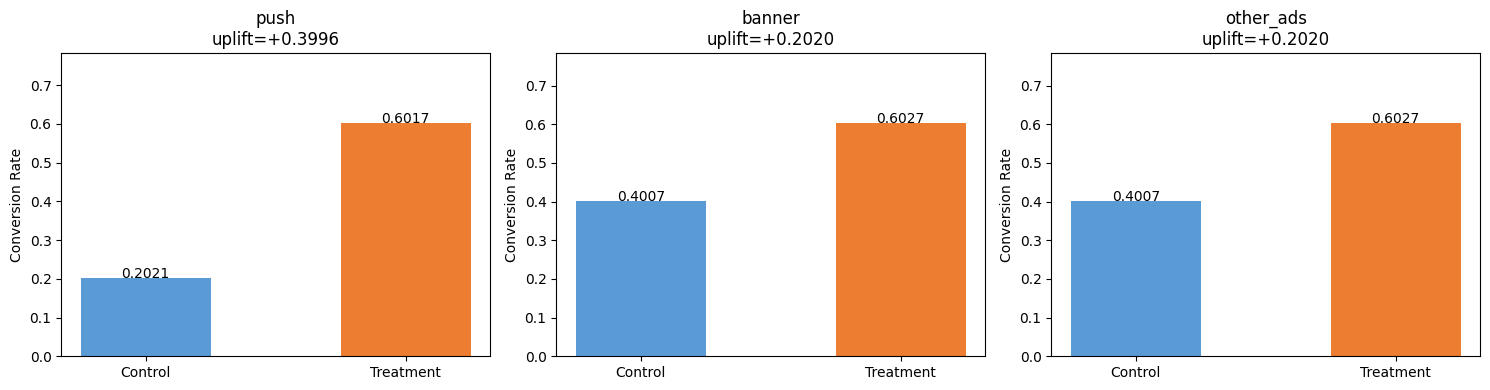

In [22]:
# =============================================================================
# 3. РАСПРЕДЕЛЕНИЕ ТАРГЕТА ПО ГРУППАМ
# =============================================================================

print("\n=== Конверсия по группам ===")
fig, axes = plt.subplots(1, len(joined), figsize=(5*len(joined), 4))
if len(joined) == 1:
    axes = [axes]

for ax, (cid, df) in zip(axes, joined.items()):
    channel = campaign_map[cid]
    cr = df.groupby('t_flag')['target'].mean()
    uplift = cr[1] - cr[0]
    bars = ax.bar(['Control', 'Treatment'], cr.values,
                  color=['#5B9BD5', '#ED7D31'], width=0.5)
    ax.set_title(f"{channel}\nuplift={uplift:+.4f}")
    ax.set_ylabel("Conversion Rate")
    ax.set_ylim(0, cr.max() * 1.3)
    for bar, val in zip(bars, cr.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('conversion_by_group.png', dpi=120)
plt.show()

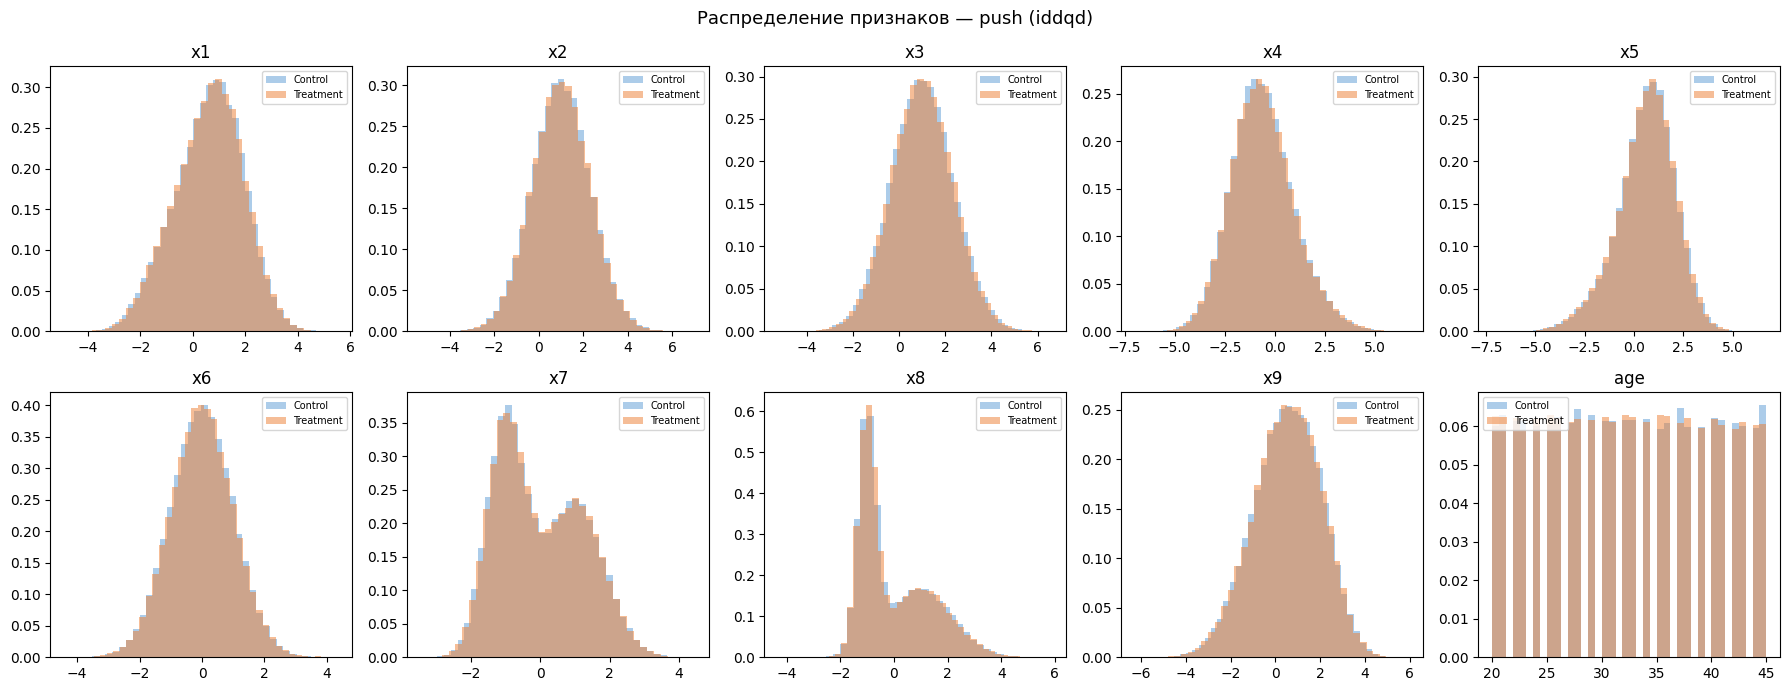

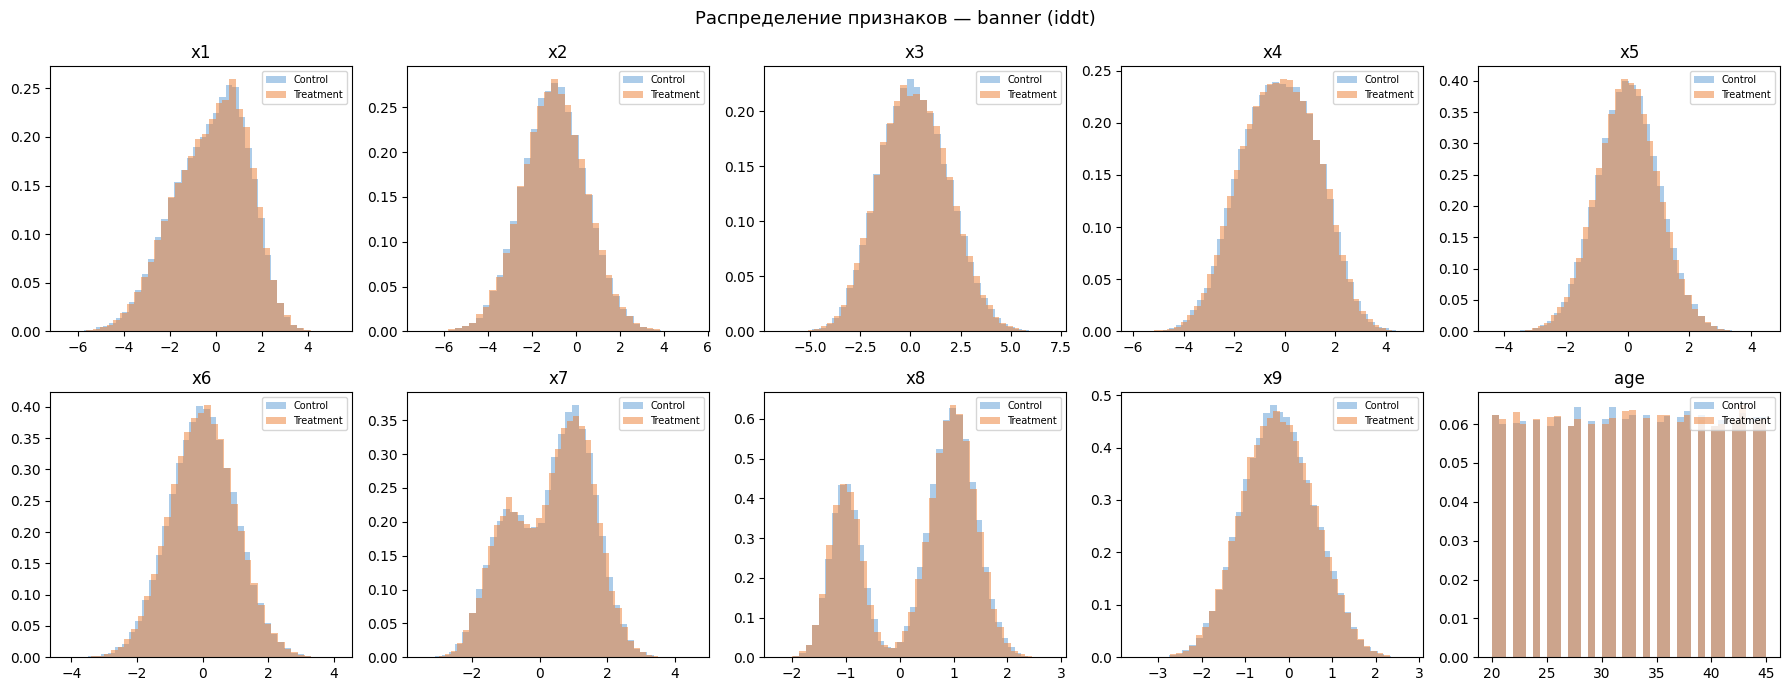

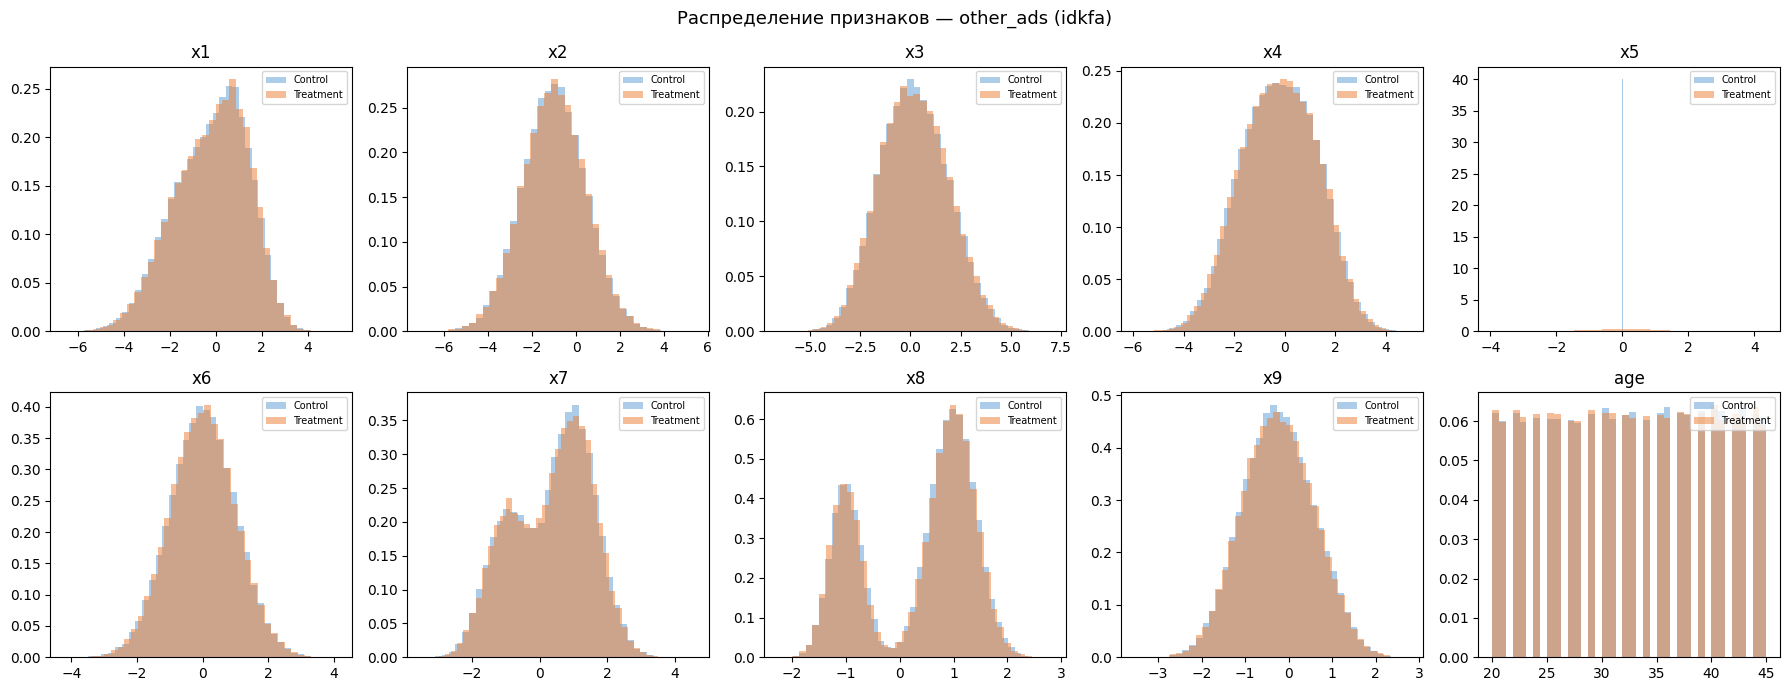

In [23]:
# =============================================================================
# 4. РАСПРЕДЕЛЕНИЕ КЛЮЧЕВЫХ ПРИЗНАКОВ (treatment vs control)
# =============================================================================

for cid, df in joined.items():
    channel = campaign_map[cid]
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    fig.suptitle(f"Распределение признаков — {channel} ({cid})", fontsize=13)

    for ax, feat in zip(axes.flatten(), FEATURE_COLS):
        t1_vals = df[df['t_flag'] == 1][feat].dropna()
        t0_vals = df[df['t_flag'] == 0][feat].dropna()
        ax.hist(t0_vals, bins=40, alpha=0.5, label='Control',   color='#5B9BD5', density=True)
        ax.hist(t1_vals, bins=40, alpha=0.5, label='Treatment', color='#ED7D31', density=True)
        ax.set_title(feat)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(f'feature_dist_{cid}.png', dpi=100)
    plt.show()


=== Uplift по квантилям признаков ===


/tmp/ipython-input-24-3831568740.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uplift_by_bin = df_feat.groupby(['bin', 't_flag'])['target'].mean().unstack()
/tmp/ipython-input-24-3831568740.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uplift_by_bin = df_feat.groupby(['bin', 't_flag'])['target'].mean().unstack()
/tmp/ipython-input-24-3831568740.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uplift_by_

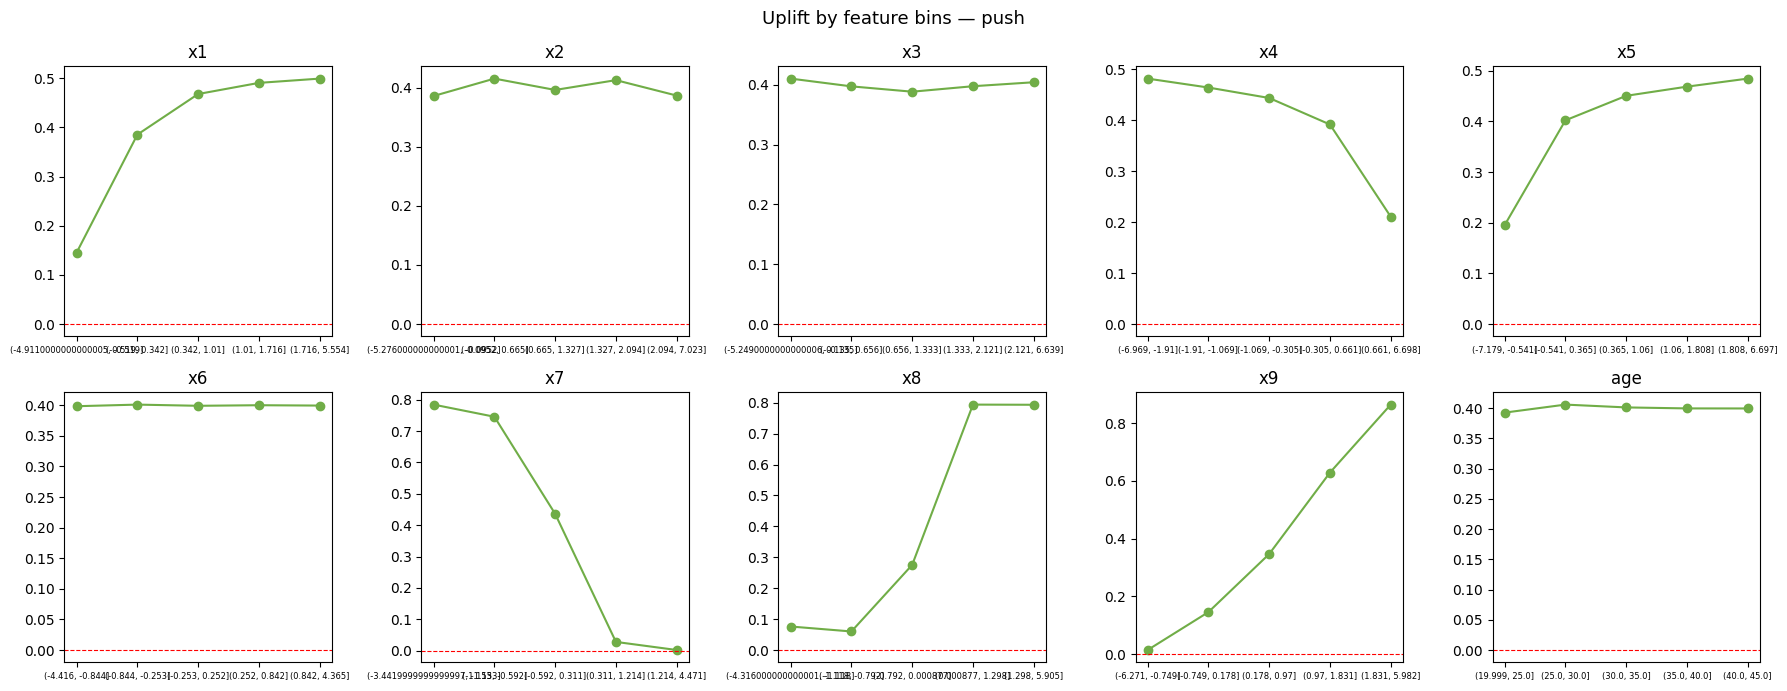

/tmp/ipython-input-24-3831568740.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uplift_by_bin = df_feat.groupby(['bin', 't_flag'])['target'].mean().unstack()
/tmp/ipython-input-24-3831568740.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uplift_by_bin = df_feat.groupby(['bin', 't_flag'])['target'].mean().unstack()
/tmp/ipython-input-24-3831568740.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uplift_by_

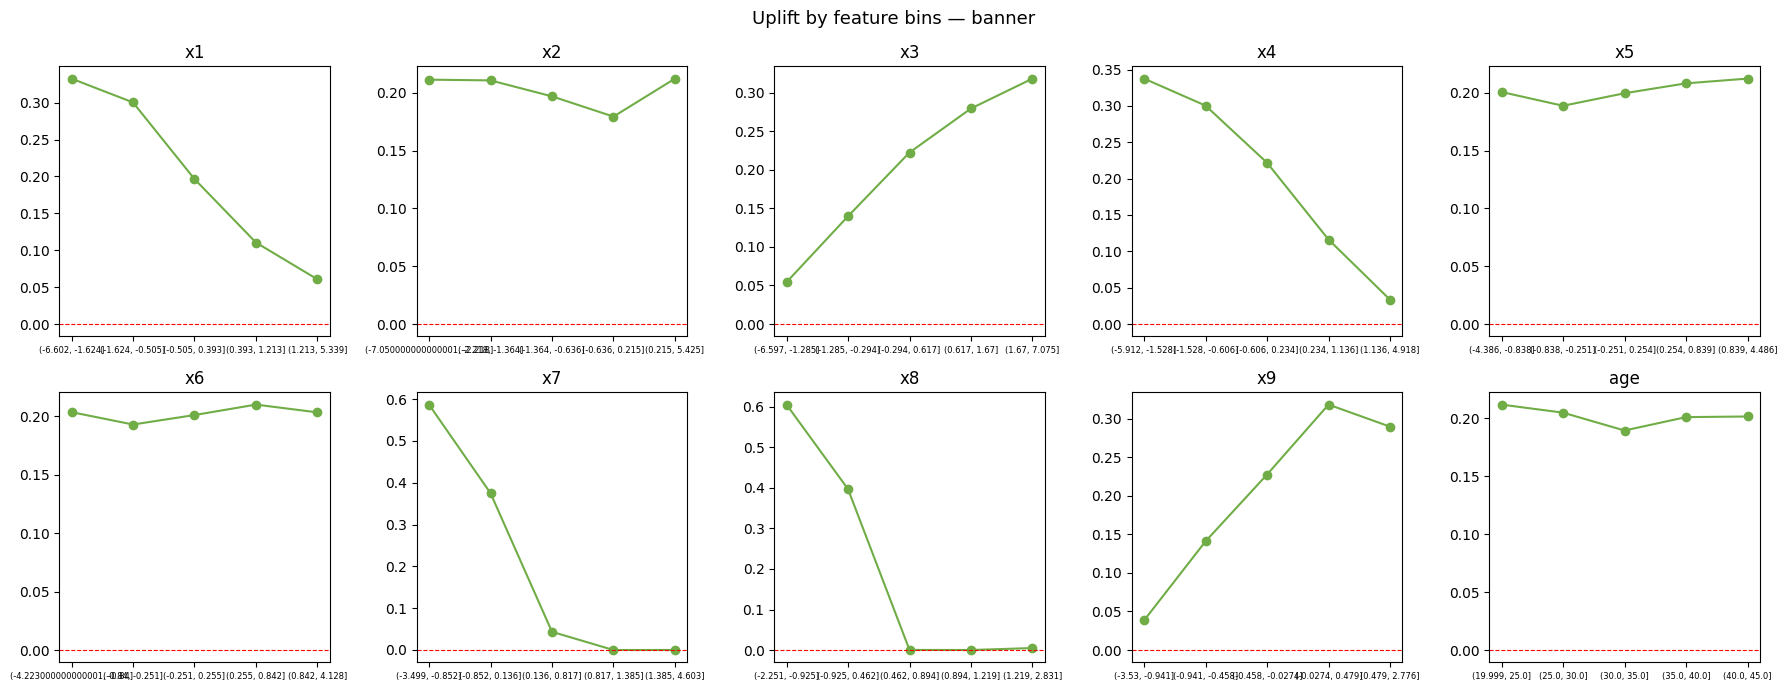

/tmp/ipython-input-24-3831568740.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uplift_by_bin = df_feat.groupby(['bin', 't_flag'])['target'].mean().unstack()
/tmp/ipython-input-24-3831568740.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uplift_by_bin = df_feat.groupby(['bin', 't_flag'])['target'].mean().unstack()
/tmp/ipython-input-24-3831568740.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uplift_by_

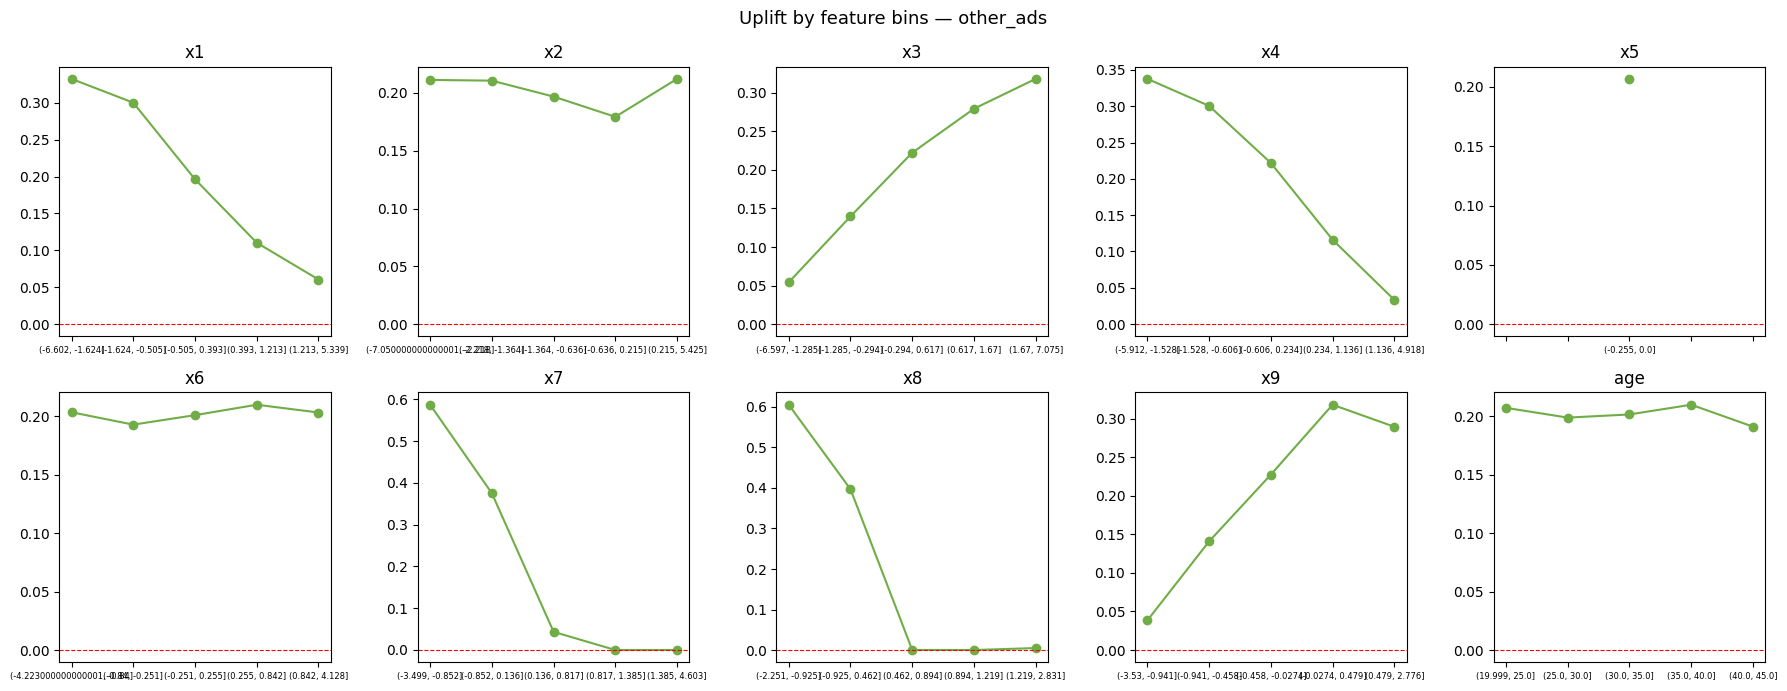

In [24]:
# =============================================================================
# 5. UPLIFT BY FEATURE (биннинг)
# =============================================================================
# Для каждого признака смотрим, как меняется uplift по квантилям
# Если uplift одинаковый во всех бинах — признак не нужен для uplift-модели

print("\n=== Uplift по квантилям признаков ===")

for cid, df in joined.items():
    channel = campaign_map[cid]
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    fig.suptitle(f"Uplift by feature bins — {channel}", fontsize=13)

    for ax, feat in zip(axes.flatten(), FEATURE_COLS):
        df_feat = df.copy()
        try:
            df_feat['bin'] = pd.qcut(df_feat[feat], q=5, duplicates='drop')
        except Exception:
            continue

        uplift_by_bin = df_feat.groupby(['bin', 't_flag'])['target'].mean().unstack()
        if 0 in uplift_by_bin.columns and 1 in uplift_by_bin.columns:
            uplift_by_bin['uplift'] = uplift_by_bin[1] - uplift_by_bin[0]
            uplift_by_bin['uplift'].plot(ax=ax, marker='o', color='#70AD47')
            ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
            ax.set_title(feat)
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelsize=6)

    plt.tight_layout()
    plt.savefig(f'uplift_by_feature_{cid}.png', dpi=100)
    plt.show()

In [25]:
# =============================================================================
# 6. РАЗМЕРЫ ГРУПП И ПРОПУСКИ
# =============================================================================

print("\n=== Пропуски после джойна ===")
for cid, df in joined.items():
    miss = df[FEATURE_COLS].isna().sum()
    if miss.any():
        print(f"{cid}:\n{miss[miss>0]}")
    else:
        print(f"{cid}: пропусков нет ✅")

print("\n=== Итоговый размер выборок ===")
for cid, df in joined.items():
    n_t1 = (df['t_flag']==1).sum()
    n_t0 = (df['t_flag']==0).sum()
    print(f"{campaign_map[cid]:12} | treatment: {n_t1:6} | control: {n_t0:6} | "
          f"ratio: {n_t1/n_t0:.2f}")


=== Пропуски после джойна ===
iddqd: пропусков нет ✅
iddt: пропусков нет ✅
idkfa: пропусков нет ✅

=== Итоговый размер выборок ===
push         | treatment:  80000 | control:  80000 | ratio: 1.00
banner       | treatment:  60000 | control:  60000 | ratio: 1.00
other_ads    | treatment:  60000 | control:  60000 | ratio: 1.00


### ваши выводы здесь

<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

In [28]:
!pip install git+https://github.com/maks-sh/scikit-uplift.git -q

  Preparing metadata (setup.py) ... done


In [30]:
!pip install scikit-learn==1.3.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 48.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
causalml 0.16.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.3.2 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
plotnine 0.14.6 requires scipy<1.16.0,>=1.8.0, but you have scipy 1.17.1 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.


In [32]:
# Патч: добавляем check_matplotlib_support обратно в sklearn.utils
import sklearn.utils
def check_matplotlib_support(caller_name):
    try:
        import matplotlib  # noqa
    except ImportError as e:
        raise ImportError(
            f"{caller_name} requires matplotlib. "
            "Install it via: pip install matplotlib"
        ) from e

sklearn.utils.check_matplotlib_support = check_matplotlib_support

# Теперь импорт пройдёт
from sklift.viz import plot_qini_curve
print("✅ sklift.viz импортирован успешно")

✅ sklift.viz импортирован успешно


In [33]:
# =============================================================================
# РАЗДЕЛ 3. UPLIFT МОДЕЛИ
# =============================================================================

# !pip install sklift lightgbm optuna -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

from sklift.models import SoloModel, TwoModels, ClassTransformation
from sklift.metrics import uplift_auc_score, qini_auc_score
from sklift.viz import plot_qini_curve

from causalml.inference.tree import UpliftRandomForestClassifier

FEATURE_COLS = ['x1','x2','x3','x4','x5','x6','x7','x8','x9','age']

# =============================================================================
# ПОДГОТОВКА ДАННЫХ
# =============================================================================

def prepare_Xy(df):
    """Возвращает X, y, treatment для одной кампании."""
    feat_cols = FEATURE_COLS + [c for c in df.columns if c.startswith('city_')]
    X  = df[feat_cols].fillna(0).reset_index(drop=True)
    y  = df['target'].reset_index(drop=True)
    tr = df['t_flag'].reset_index(drop=True)
    return X, y, tr

def train_val_split(X, y, tr, val_size=0.2, random_state=42):
    from sklearn.model_selection import train_test_split
    idx = np.arange(len(X))
    idx_tr, idx_val = train_test_split(idx, test_size=val_size,
                                       random_state=random_state,
                                       stratify=tr)
    return (X.iloc[idx_tr], y.iloc[idx_tr], tr.iloc[idx_tr],
            X.iloc[idx_val], y.iloc[idx_val], tr.iloc[idx_val])

# Результаты по всем кампаниям
all_models   = {}   # cid -> dict моделей
all_scores   = []   # для итоговой таблицы

# =============================================================================
# ЦИКЛ ПО КАМПАНИЯМ
# =============================================================================

for cid, df in joined.items():
    channel = campaign_map[cid]
    print(f"\n{'='*60}")
    print(f"  КАМПАНИЯ: {cid}  ({channel})")
    print(f"{'='*60}")

    X, y, tr = prepare_Xy(df)
    X_tr, y_tr, t_tr, X_val, y_val, t_val = train_val_split(X, y, tr)

    models_this = {}

    # ------------------------------------------------------------------
    # 1. SOLO MODEL (S-Learner)
    # ------------------------------------------------------------------
    print("\n[1] SoloModel")

    base_solo = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=42))
    ])

    solo = SoloModel(base_solo)
    solo.fit(X_tr, y_tr, t_tr)
    uplift_solo = solo.predict(X_val)
    score_solo  = qini_auc_score(y_val, uplift_solo, t_val)
    print(f"   Qini AUC: {score_solo:.4f}")
    models_this['SoloModel'] = (solo, uplift_solo, score_solo)

    # ------------------------------------------------------------------
    # 2. TWO MODEL (T-Learner) с калибровкой
    # ------------------------------------------------------------------
    print("\n[2] TwoModels (T-Learner) + калибровка")

    base_t = CalibratedClassifierCV(
        LGBMClassifier(n_estimators=200, learning_rate=0.05,
                       num_leaves=31, random_state=42, verbose=-1),
        cv=3, method='isotonic'
    )
    base_c = CalibratedClassifierCV(
        LGBMClassifier(n_estimators=200, learning_rate=0.05,
                       num_leaves=31, random_state=42, verbose=-1),
        cv=3, method='isotonic'
    )

    two = TwoModels(
        estimator_trt=base_t,
        estimator_ctrl=base_c,
        method='vanilla'
    )
    two.fit(X_tr, y_tr, t_tr)
    uplift_two = two.predict(X_val)
    score_two  = qini_auc_score(y_val, uplift_two, t_val)
    print(f"   Qini AUC: {score_two:.4f}")
    models_this['TwoModels'] = (two, uplift_two, score_two)

    # ------------------------------------------------------------------
    # 3. CLASS TRANSFORMATION
    # ------------------------------------------------------------------
    print("\n[3] ClassTransformation")

    base_ct = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    CalibratedClassifierCV(
                       LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                      num_leaves=31, random_state=42, verbose=-1),
                       cv=3, method='sigmoid'))
    ])

    ct = ClassTransformation(base_ct)
    ct.fit(X_tr, y_tr, t_tr)
    uplift_ct = ct.predict(X_val)
    score_ct  = qini_auc_score(y_val, uplift_ct, t_val)
    print(f"   Qini AUC: {score_ct:.4f}")
    models_this['ClassTransformation'] = (ct, uplift_ct, score_ct)

    # ------------------------------------------------------------------
    # 4. UPLIFT RANDOM FOREST (CausalML)
    # ------------------------------------------------------------------
    print("\n[4] UpliftRandomForest (CausalML)")

    urf = UpliftRandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=50,
        evaluationFunction='KL',
        control_name='0',
        random_state=42,
        n_jobs=-1
    )
    # CausalML ожидает treatment как строки
    t_tr_str  = t_tr.astype(str)
    t_val_str = t_val.astype(str)

    urf.fit(X_tr.values, t_tr_str.values, y_tr.values)
    uplift_urf_raw = urf.predict(X_val.values)
    # predict возвращает dict или DataFrame — берём колонку treatment '1'
    if isinstance(uplift_urf_raw, np.ndarray):
        uplift_urf = uplift_urf_raw[:, 0]
    else:
        uplift_urf = uplift_urf_raw['1'].values

    score_urf = qini_auc_score(y_val, uplift_urf, t_val)
    print(f"   Qini AUC: {score_urf:.4f}")
    models_this['UpliftRandomForest'] = (urf, uplift_urf, score_urf)

    # ------------------------------------------------------------------
    # 5. ТЮНИНГ ЛУЧШЕЙ МОДЕЛИ (Optuna + TwoModels)
    # ------------------------------------------------------------------
    print("\n[5] Тюнинг TwoModels (Optuna)")

    def objective(trial):
        params = {
            'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves':    trial.suggest_int('num_leaves', 15, 63),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        }
        m_t = CalibratedClassifierCV(
            LGBMClassifier(**params, random_state=42, verbose=-1),
            cv=3, method='isotonic'
        )
        m_c = CalibratedClassifierCV(
            LGBMClassifier(**params, random_state=42, verbose=-1),
            cv=3, method='isotonic'
        )
        model = TwoModels(estimator_trt=m_t, estimator_ctrl=m_c, method='vanilla')
        model.fit(X_tr, y_tr, t_tr)
        preds = model.predict(X_val)
        return qini_auc_score(y_val, preds, t_val)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30, show_progress_bar=False)

    best_p = study.best_params
    print(f"   Лучшие параметры: {best_p}")
    print(f"   Лучший Qini AUC:  {study.best_value:.4f}")

    # Переобучаем с лучшими параметрами
    m_t_best = CalibratedClassifierCV(
        LGBMClassifier(**best_p, random_state=42, verbose=-1),
        cv=3, method='isotonic'
    )
    m_c_best = CalibratedClassifierCV(
        LGBMClassifier(**best_p, random_state=42, verbose=-1),
        cv=3, method='isotonic'
    )
    two_tuned = TwoModels(estimator_trt=m_t_best, estimator_ctrl=m_c_best,
                          method='vanilla')
    two_tuned.fit(X_tr, y_tr, t_tr)
    uplift_tuned = two_tuned.predict(X_val)
    score_tuned  = qini_auc_score(y_val, uplift_tuned, t_val)
    print(f"   Qini AUC (tuned): {score_tuned:.4f}")
    models_this['TwoModels_tuned'] = (two_tuned, uplift_tuned, score_tuned)

    all_models[cid] = models_this

    # ------------------------------------------------------------------
    # QINI CURVES — все модели на одном графике
    # ------------------------------------------------------------------
    print(f"\n[Qini curves — {channel}]")
    fig, ax = plt.subplots(figsize=(8, 5))

    colors = ['#5B9BD5', '#ED7D31', '#70AD47', '#FFC000', '#7030A0']
    for (name, (_, preds, score)), color in zip(models_this.items(), colors):
        plot_qini_curve(y_val, preds, t_val,
                        label=f'{name} (AUC={score:.4f})',
                        color=color, ax=ax)

    ax.set_title(f'Qini Curves — {channel} ({cid})')
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'qini_{cid}.png', dpi=120)
    plt.show()

    # Сохраняем строки для сводной таблицы
    for name, (_, _, score) in models_this.items():
        all_scores.append({
            'campaign': cid, 'channel': channel,
            'model': name, 'qini_auc': round(score, 4)
        })

# =============================================================================
# СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
# =============================================================================

scores_df = pd.DataFrame(all_scores)
print("\n=== ИТОГОВАЯ ТАБЛИЦА QINI AUC ===")
print(scores_df.pivot_table(
    index='model', columns='channel', values='qini_auc'
).to_string())

best_per_campaign = scores_df.loc[scores_df.groupby('campaign')['qini_auc'].idxmax()]
print("\n=== ЛУЧШАЯ МОДЕЛЬ ПО КАЖДОЙ КАМПАНИИ ===")
print(best_per_campaign[['campaign','channel','model','qini_auc']].to_string(index=False))

RuntimeError: empty_like method already has a different docstring

In [ ]:
!

<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [ ]:
# ваш код здесь

### ваши выводы здесь